In [1]:
from google.colab import files
uploaded = files.upload()

Saving fraud_smote.csv to fraud_smote.csv


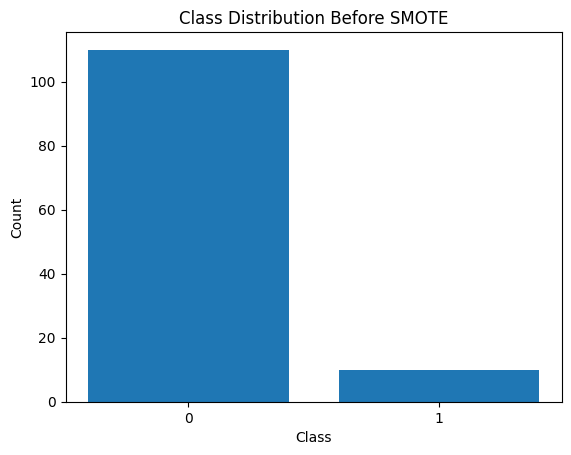

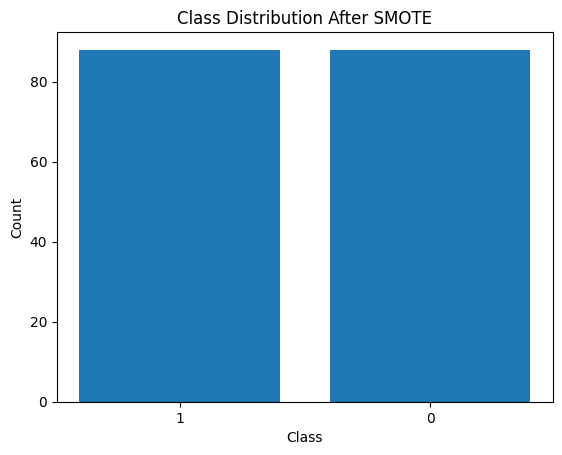

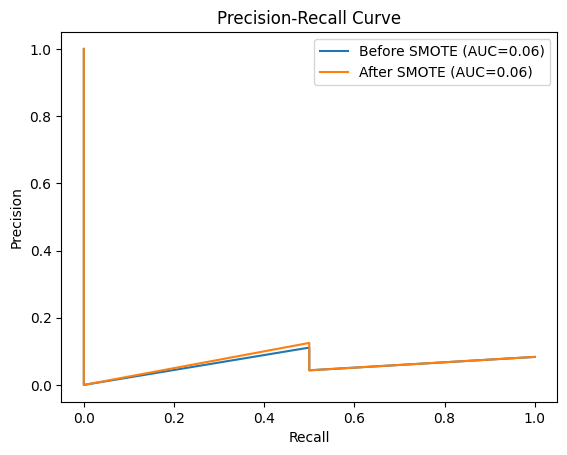

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# Corrected path for Colab
df = pd.read_csv("fraud_smote.csv")

X = df[['Amount', 'Time', 'Feature1', 'Feature2']]
y = df['Fraud']

class_counts = y.value_counts()

plt.figure()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_prob_before = model_before.predict_proba(X_test)[:, 1]
precision_before, recall_before, _ = precision_recall_curve(y_test, y_prob_before)
pr_auc_before = auc(recall_before, precision_before)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

class_counts_after = pd.Series(y_train_sm).value_counts()

plt.figure()
plt.bar(class_counts_after.index.astype(str), class_counts_after.values)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_sm, y_train_sm)

y_prob_after = model_after.predict_proba(X_test)[:, 1]
precision_after, recall_after, _ = precision_recall_curve(y_test, y_prob_after)
pr_auc_after = auc(recall_after, precision_after)

plt.figure()
plt.plot(recall_before, precision_before, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(recall_after, precision_after, label=f"After SMOTE (AUC={pr_auc_after:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()